# **1. Business Problem Understanding**

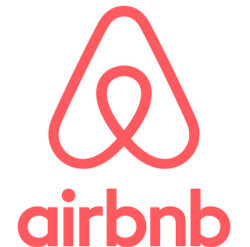

The short-term rental market in Berlin operates with intense competition which requires hosts and property investors to make precise pricing choices for their Airbnb listings. Restaurants that set nightly prices through guesswork or without complete market data risk losing money while their establishments remain underutilized. The research project establishes a data-based pricing system which determines Berlin Airbnb nightly prices through analysis of property details and geographical positions. The solution enables investment evaluation through its ability to convert predicted prices into profitability metrics which users can use for better business choice-making.

# **2. Data Collection**

For this project, an existing dataset from Kaggle is used:

https://www.kaggle.com/datasets/thedevastator/berlin-airbnb-ratings-and-reviews-overview/data?select=Airbnb+Berlin.csv


## **2.1. Dataset Overview**

The dataset contains organized data about Berlin Airbnb listings which includes details about properties and hosts and locations and booking choices and quality ratings based on guest reviews. The dataset contains both numerical and categorical data which includes room types and accommodation sizes and pricing elements and neighborhood details and guest evaluation scores. The dataset includes geographic coordinates which enable researchers to perform spatial analysis. The diverse set of features allows users to create complete models of nightly prices which enables them to perform both pricing and investment evaluation tasks.

# **3. Data Exploration**

## **3.1. Importing Necessary Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os

## **3.2. Explanatory Data Analysis(EDA)**

The dataset contains a large number of records with mixed numerical and categorical features, indicating the need for preprocessing and feature engineering before modeling.


In [ ]:
df = pd.read_csv('/content/Airbnb Berlin.csv')

print(df.shape)

df.head()

/tmp/ipython-input-2402145755.py:1: DtypeWarning: Columns (19,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/Airbnb Berlin.csv')


(456961, 47)


,index,Review ID,review_date,Reviewer ID,Reviewer Name,Comments,Listing ID,Listing URL,Listing Name,Host ID,...,Last Review,Overall Rating,Accuracy Rating,Cleanliness Rating,Checkin Rating,Communication Rating,Location Rating,Value Rating,Instant Bookable,Business Travel Ready
0,0,58660447.0,01-03-16,14876562.0,Dennis,"Very nice, clean appartement! Josh was really ...",10002699,https://www.airbnb.com/rooms/10002699,Trendy and peaceful KreuzkÃ¶lln,44696672,...,01-03-16,100.0,8.0,10.0,6.0,10.0,10.0,10.0,f,f
1,1,NaN,NaN,NaN,NaN,NaN,10002922,https://www.airbnb.com/rooms/10002922,Sehr zentrale Wohnung in Berlin,45848709,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,f
2,2,58663795.0,01-03-16,49367757.0,Andreea,Aki is really nice and friendly. We had an ama...,10006647,https://www.airbnb.com/rooms/10006647,Very central and very quite,40791092,...,02-12-17,92.0,9.0,8.0,9.0,10.0,10.0,9.0,f,f
3,3,59003619.0,01-05-16,46694292.0,Sasha,Aki is a very nice dude with a clean place in ...,10006647,https://www.airbnb.com/rooms/10006647,Very central and very quite,40791092,...,02-12-17,92.0,9.0,8.0,9.0,10.0,10.0,9.0,f,f
4,4,66845661.0,03-25-16,54542819.0,Yohana,Aki's place was easy to find and located in th...,10006647,https://www.airbnb.com/rooms/10006647,Very central and very quite,40791092,...,02-12-17,92.0,9.0,8.0,9.0,10.0,10.0,9.0,f,f


In [ ]:
print("--- BASIC INFO ---")
print(df.info())

--- BASIC INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456961 entries, 0 to 456960
Data columns (total 47 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   index                  456961 non-null  int64  
 1   Review ID              452805 non-null  float64
 2   review_date            452805 non-null  object 
 3   Reviewer ID            452805 non-null  float64
 4   Reviewer Name          452805 non-null  object 
 5   Comments               452595 non-null  object 
 6   Listing ID             456961 non-null  int64  
 7   Listing URL            456961 non-null  object 
 8   Listing Name           456756 non-null  object 
 9   Host ID                456961 non-null  int64  
 10  Host URL               456961 non-null  object 
 11  Host Name              456913 non-null  object 
 12  Host Since             456913 non-null  object 
 13  Host Response Time     398194 non-null  object 
 14  Host Response Rat

Mixed-type columns were identified and the target price variable was cleaned and converted to a numeric format to ensure consistency for model training.


In [ ]:
mixed_cols = [19, 32]
print("Columns with mixed types:", df.columns[mixed_cols].tolist())

Columns with mixed types: ['Postal Code', 'Price']


In [ ]:
if 'Price' in df.columns:
    df['Price'] = (
        df['Price']
        .astype(str)
        .str.replace(r'[^\d\.]', '', regex=True)
        .replace('', np.nan)
        .astype(float)
    )

    print(df[['Price']].dtypes)

Price    float64
dtype: object


The price distribution is right-skewed, and applying a logarithmic transformation helps stabilize variance and reduce the impact of extreme values.


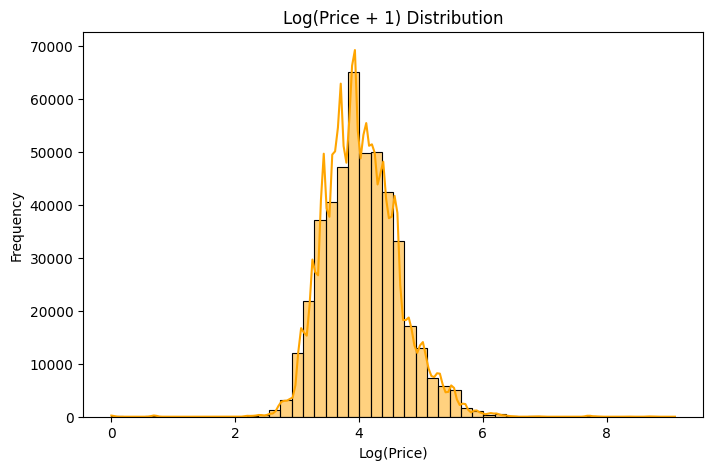

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df['Price']), bins=50, kde=True, color='orange')
plt.title("Log(Price + 1) Distribution")
plt.xlabel("Log(Price)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
print("Price statistics:")
print(df['Price'].describe(percentiles=[.01,.05,.5,.95,.99]))

df_eda = df[df['Price'] < df['Price'].quantile(0.99)]

Price statistics:
count    456961.000000
mean         69.150667
std          90.638069
min           0.000000
1%           17.000000
5%           23.000000
50%          53.000000
95%         160.000000
99%         269.000000
max        9000.000000
Name: Price, dtype: float64


Entire home/apartment listings tend to have significantly higher prices than private and shared rooms, highlighting room type as a key pricing factor.


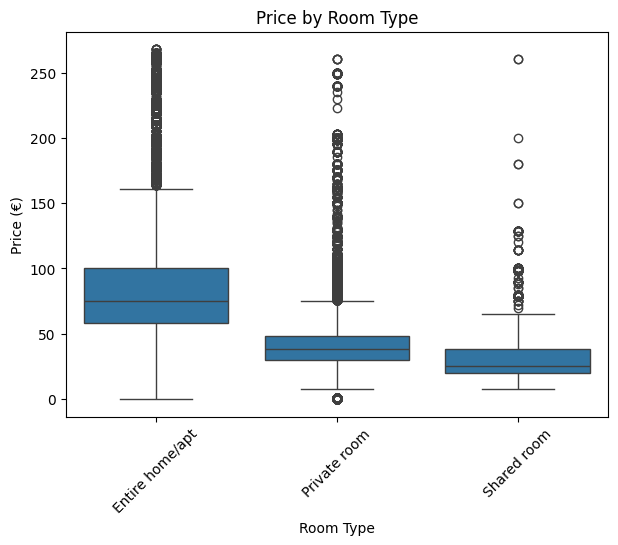

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Room Type', y='Price', data=df_eda)
plt.title("Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price (€)")
plt.xticks(rotation=45)
plt.show()

Average nightly prices vary significantly across neighborhoods, indicating that location is a strong determinant of Airbnb pricing in Berlin.


/tmp/ipython-input-2258192751.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_neigh.values, y=top_neigh.index, palette='viridis')


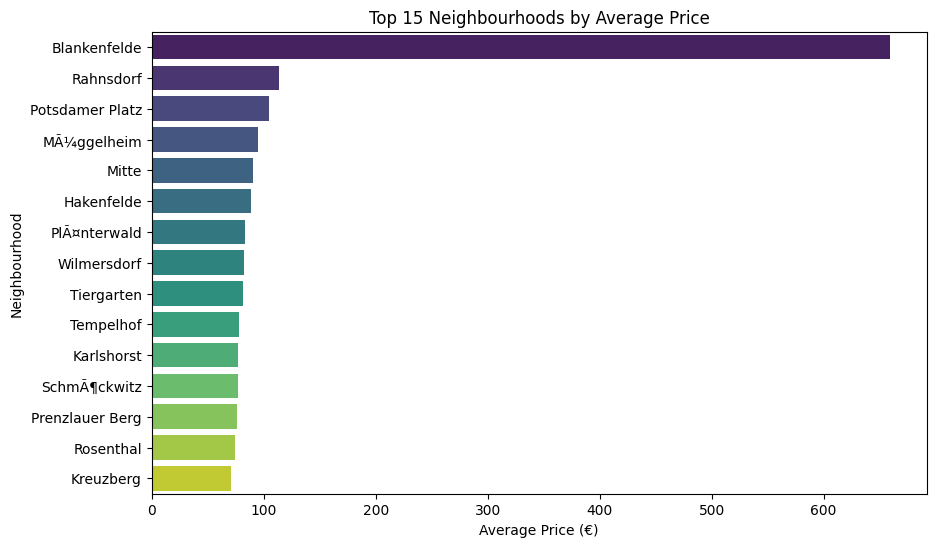

In [ ]:
if 'neighbourhood' in df.columns:
    plt.figure(figsize=(10,6))
    top_neigh = df.groupby('neighbourhood')['Price'].mean().sort_values(ascending=False).head(15)
    sns.barplot(x=top_neigh.values, y=top_neigh.index, palette='viridis')
    plt.title("Top 15 Neighbourhoods by Average Price")
    plt.xlabel("Average Price (€)")
    plt.ylabel("Neighbourhood")
    plt.show()

The correlation heatmap shows moderate correlations between price and capacity-related features, while most numerical variables remain weakly correlated, supporting the use of tree-based models.


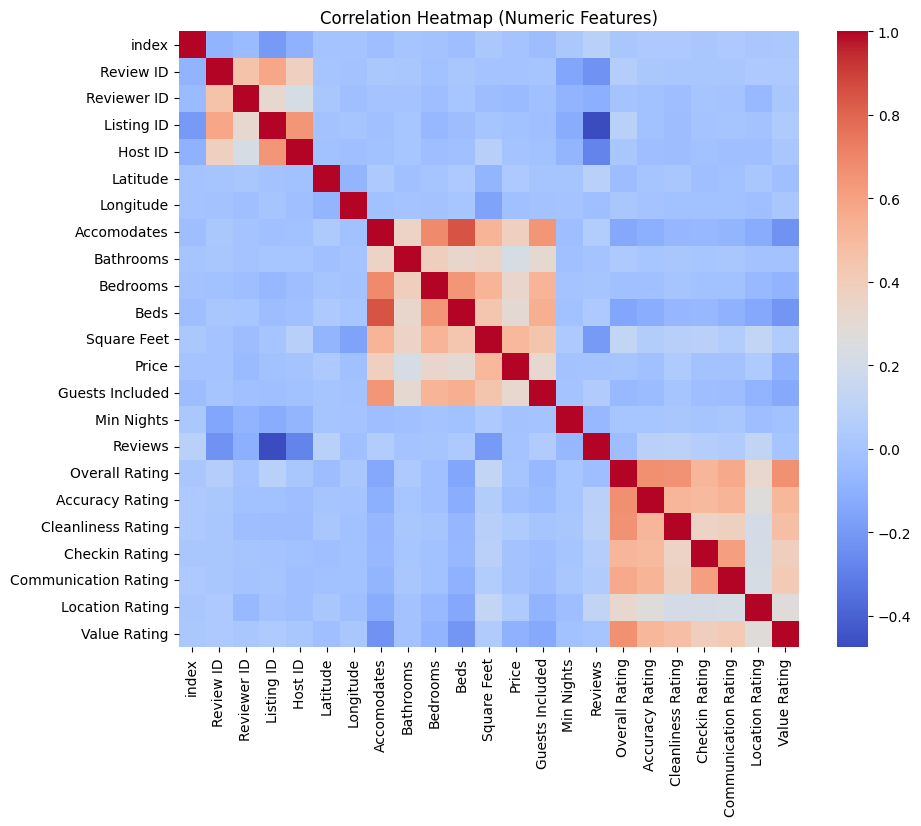

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

Price shows the strongest correlations with size and capacity-related features such as square footage, accommodates, and number of bedrooms.


In [ ]:
if 'Price' in corr.columns:
    print("\nTop numeric correlations with Price:")
    print(corr['Price'].sort_values(ascending=False).head(10))


Top numeric correlations with Price:
Price                 1.000000
Square Feet           0.506268
Accomodates           0.377637
Bedrooms              0.334184
Guests Included       0.321212
Beds                  0.306840
Bathrooms             0.227511
Cleanliness Rating    0.042171
Location Rating       0.039741
Latitude              0.030506
Name: Price, dtype: float64


# **4. Data Preprocessing**

## **4.1. Missing Values Check**

Several features contain missing values, particularly in host response metrics and review-related fields, indicating the need for appropriate data cleaning or imputation strategies.


In [ ]:
missing = df.isna().sum()
missing_nonzero = missing[missing != 0]
print(missing_nonzero)

Review ID                 4156
review_date               4156
Reviewer ID               4156
Reviewer Name             4156
Comments                  4366
Listing Name               205
Host Name                   48
Host Since                  48
Host Response Time       58767
Host Response Rate       58767
Is Superhost                48
City                        33
Postal Code               7703
Bathrooms                  943
Bedrooms                   717
Beds                        90
Square Feet             428286
First Review              4156
Last Review               4156
Overall Rating            4719
Accuracy Rating           4752
Cleanliness Rating        4750
Checkin Rating            4773
Communication Rating      4756
Location Rating           4775
Value Rating              4776
dtype: int64


## **4.2. Removing Unnecessary Columns & Filling Columns**

Irrelevant and high-cardinality columns such as review text, identifiers, URLs, and descriptive metadata were removed to reduce noise and improve model efficiency. Numerical features with missing values were handled using median imputation, while columns with excessive missingness (e.g., square footage and host response time) were excluded from the modeling dataset. As a result, a refined feature set containing core location, property, capacity, and booking-related variables was obtained for model training.

In [ ]:
drop_cols = [
    'Review ID','Reviewer ID','Reviewer Name','Comments',
    'Listing Name','Listing URL','Host Name','Host URL',
    'First Review','Last Review','City','Host Since',
    'Postal Code',' review_date','Is Superhost'
]
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

In [ ]:
df.columns = df.columns.str.strip().str.replace(r'\s+', ' ', regex=True)

drop_cols = ['review_date', 'Host Since','Is Superhost','Host Response Rate']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True, errors='ignore')

In [ ]:
fill_median = ['Bathrooms','Bedrooms','Beds','Price','Overall Rating',
               'Accuracy Rating','Cleanliness Rating','Checkin Rating','Communication Rating',
               'Location Rating','Value Rating']
for c in fill_median:
    if c in df.columns:
        df[c] = df[c].fillna(df[c].median())

In [ ]:
missing = df.isna().sum()
missing_nonzero = missing[missing != 0]
print("After Cleaning - Null Values\n",missing_nonzero)

After Cleaning - Null Values
 Host Response Time     58767
Square Feet           428286
dtype: int64


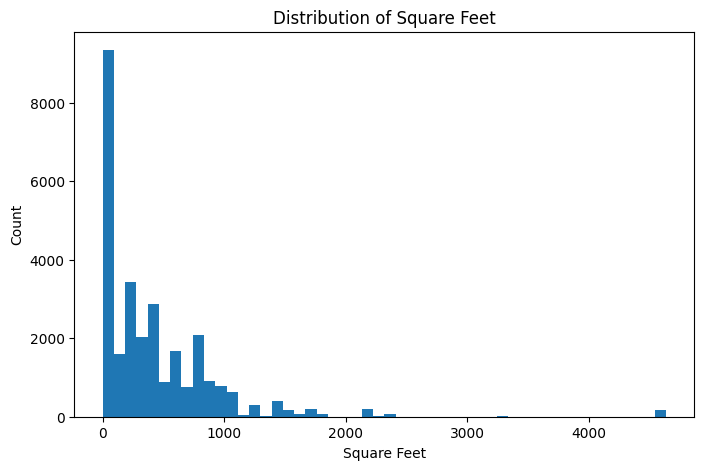

,count,mean,std,min,25%,50%,75%,max
Square Feet,28675.0,419.721709,541.567497,0.0,0.0,269.0,646.0,4639.0


In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['Square Feet'], bins=50)
plt.title('Distribution of Square Feet')
plt.xlabel('Square Feet')
plt.ylabel('Count')
plt.show()

df_squarefeet = df['Square Feet'].describe().to_frame().T
df_squarefeet

In [ ]:
df_testing = df[['Square Feet', 'Bedrooms', 'Bathrooms', 'Beds']].sample(20, random_state=42)
df_testing

,Square Feet,Bedrooms,Bathrooms,Beds
425975,NaN,1.0,1.0,1.0
391704,NaN,1.0,1.0,1.0
317860,NaN,1.0,1.0,0.0
240086,NaN,1.0,1.0,1.0
292949,NaN,1.0,1.0,4.0
319243,NaN,1.0,1.0,2.0
206009,NaN,3.0,1.5,3.0
443603,NaN,1.0,1.0,1.0
213534,NaN,1.0,1.0,2.0
295415,NaN,2.0,1.0,3.0


In [ ]:
drop_cols_model = [
    'index','Country','Country Code','City',
    'Listing ID','Host ID','Accuracy Rating','Cleanliness Rating','Checkin Rating','Communication Rating',
    'Location Rating','Value Rating','Overall Rating',
    'Is Superhost','Is Exact Location','Host Response Time','Reviews','Square Feet'
]

df.drop(columns=[c for c in drop_cols_model if c in df.columns], inplace=True, errors='ignore')

print("Remaining columns after feature cleaning:")
print(df.columns.tolist())

Remaining columns after feature cleaning:
['neighbourhood', 'Neighborhood Group', 'Latitude', 'Longitude', 'Property Type', 'Room Type', 'Accomodates', 'Bathrooms', 'Bedrooms', 'Beds', 'Price', 'Guests Included', 'Min Nights', 'Instant Bookable', 'Business Travel Ready']


In [ ]:
print("Unique neighbourhoods:")
print(sorted(df['neighbourhood'].dropna().unique().tolist())[:50])

print("\nUnique neighborhood groups:")
print(sorted(df['Neighborhood Group'].dropna().unique().tolist())[:50])

Unique neighbourhoods:
['Adlershof', 'Alt-HohenschÃ¶nhausen', 'Alt-Treptow', 'Altglienicke', 'Baumschulenweg', 'Biesdorf', 'Blankenburg', 'Blankenfelde', 'Bohnsdorf', 'Britz', 'Buch', 'Buckow', 'Charlottenburg', 'Charlottenburg-Nord', 'Dahlem', 'Falkenberg', 'Falkenhagener Feld', 'Fennpfuhl', 'FranzÃ¶sisch Buchholz', 'Friedenau', 'Friedrichsfelde', 'Friedrichshagen', 'Friedrichshain', 'Frohnau', 'Gatow', 'Gropiusstadt', 'Grunewald', 'GrÃ¼nau', 'Hakenfelde', 'Halensee', 'Hansaviertel', 'Haselhorst', 'Heiligensee', 'Heinersdorf', 'Hellersdorf', 'Hermsdorf', 'Johannisthal', 'Karlshorst', 'Karow', 'Kaulsdorf', 'Kladow', 'KonradshÃ¶he', 'Kreuzberg', 'KÃ¶penick', 'Lankwitz', 'Lichtenberg', 'Lichtenrade', 'Lichterfelde', 'Mahlsdorf', 'Mariendorf']

Unique neighborhood groups:
['Charlottenburg-Wilm.', 'Friedrichshain-Kreuzberg', 'Lichtenberg', 'Marzahn - Hellersdorf', 'Mitte', 'NeukÃ¶lln', 'Pankow', 'Reinickendorf', 'Spandau', 'Steglitz - Zehlendorf', 'Tempelhof - SchÃ¶neberg', 'Treptow - KÃ¶p

## **4.3. Fixing Letters**

Text encoding issues in categorical location features were resolved to ensure consistent and readable neighborhood and district names. This step prevents duplicated categories caused by character encoding inconsistencies and improves the reliability of categorical encoding during modeling. After normalization, all categorical and numerical features were verified to have correct data types for downstream processing.

In [ ]:
def fix_encoding(s):
    try:
        return s.encode('latin1').decode('utf-8')
    except Exception:
        return s

for c in ['neighbourhood', 'Neighborhood Group']:
    if c in df.columns:
        df[c] = df[c].astype(str).apply(fix_encoding)

neigh_uniques = sorted(df['neighbourhood'].unique().tolist())
group_uniques = sorted(df['Neighborhood Group'].unique().tolist())

print(neigh_uniques)
print(group_uniques)

['Adlershof', 'Alt-Hohenschönhausen', 'Alt-Treptow', 'Altglienicke', 'Baumschulenweg', 'Biesdorf', 'Blankenburg', 'Blankenfelde', 'Bohnsdorf', 'Britz', 'Buch', 'Buckow', 'Charlottenburg', 'Charlottenburg-Nord', 'Dahlem', 'Falkenberg', 'Falkenhagener Feld', 'Fennpfuhl', 'Französisch Buchholz', 'Friedenau', 'Friedrichsfelde', 'Friedrichshagen', 'Friedrichshain', 'Frohnau', 'Gatow', 'Gropiusstadt', 'Grunewald', 'Grünau', 'Hakenfelde', 'Halensee', 'Hansaviertel', 'Haselhorst', 'Heiligensee', 'Heinersdorf', 'Hellersdorf', 'Hermsdorf', 'Johannisthal', 'Karlshorst', 'Karow', 'Kaulsdorf', 'Kladow', 'Konradshöhe', 'Kreuzberg', 'Köpenick', 'Lankwitz', 'Lichtenberg', 'Lichtenrade', 'Lichterfelde', 'Mahlsdorf', 'Mariendorf', 'Marienfelde', 'Marzahn', 'Mitte', 'Moabit', 'Märkisches Viertel', 'Müggelheim', 'Neu-Hohenschönhausen', 'Neukölln', 'Niederschöneweide', 'Niederschönhausen', 'Nikolassee', 'Oberschöneweide', 'Pankow', 'Plänterwald', 'Potsdamer Platz', 'Prenzlauer Berg', 'Rahnsdorf', 'Reinicke

In [ ]:
print(df.dtypes)

neighbourhood             object
Neighborhood Group        object
Latitude                 float64
Longitude                float64
Property Type             object
Room Type                 object
Accomodates                int64
Bathrooms                float64
Bedrooms                 float64
Beds                     float64
Price                    float64
Guests Included            int64
Min Nights                 int64
Instant Bookable          object
Business Travel Ready     object
dtype: object


In [ ]:
df.head()

,neighbourhood,Neighborhood Group,Latitude,Longitude,Property Type,Room Type,Accomodates,Bathrooms,Bedrooms,Beds,Price,Guests Included,Min Nights,Instant Bookable,Business Travel Ready
0,Neukölln,Neukölln,52.49234,13.42994,Apartment,Entire home/apt,4,1.0,2.0,2.0,60.0,1,1,f,f
1,Prenzlauer Berg,Pankow,52.53292,13.41502,Apartment,Entire home/apt,2,1.0,1.0,1.0,52.0,1,1,f,f
2,Mitte,Mitte,52.52134,13.41866,Apartment,Private room,2,1.0,1.0,1.0,35.0,1,1,f,f
3,Mitte,Mitte,52.52134,13.41866,Apartment,Private room,2,1.0,1.0,1.0,35.0,1,1,f,f
4,Mitte,Mitte,52.52134,13.41866,Apartment,Private room,2,1.0,1.0,1.0,35.0,1,1,f,f


# **5. Feature Engineering**

## **5.1. Encoding**

Boolean features were converted into binary numerical values, and categorical variables were encoded using one-hot encoding to make them suitable for machine learning models.


In [ ]:
bool_cols = ['Instant Bookable', 'Business Travel Ready']
for c in bool_cols:
    if c in df.columns:
        df[c] = df[c].astype(str).str.lower().map({'t': 1, 'true': 1, '1': 1, 'f': 0, 'false': 0, '0': 0}).fillna(0).astype(int)

In [ ]:
cat_cols = ['neighbourhood', 'Neighborhood Group', 'Property Type', 'Room Type']
cat_cols = [c for c in cat_cols if c in df.columns]

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

## **5.2. Splitting Test and Train Datasets**

The dataset was split into training and testing subsets to enable unbiased evaluation of model performance on unseen data.


In [ ]:
X = df.drop(columns=['Price'])
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (365568, 149)
Testing data shape: (91393, 149)


# **6. Model Training and Evaluation**

Both Random Forest and Gradient Boosting models were trained and evaluated using MAE, RMSE, and R² metrics. The Random Forest model achieved superior performance on the test set and showed good generalization when comparing training and test results, leading to its selection as the final model. Feature importance analysis indicates that location, capacity-related attributes, and property characteristics are the most influential factors in nightly price prediction.

In [ ]:
def eval_reg(y_true, y_pred, name="Model"):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{name:>18} -> MAE: {mae:.2f} | RMSE: {rmse:.2f} | R^2: {r2:.3f}")
    return {"name":name, "mae":mae, "rmse":rmse, "r2":r2}

In [ ]:
rf = RandomForestRegressor(
    n_estimators=400,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_metrics = eval_reg(y_test, rf_pred, "RandomForest")

      RandomForest -> MAE: 1.02 | RMSE: 211.50 | R^2: 0.973


In [ ]:
gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_metrics = eval_reg(y_test, gb_pred, "GradientBoosting")

  GradientBoosting -> MAE: 17.83 | RMSE: 1812.08 | R^2: 0.768


In [ ]:
best_model, best_pred, best_name, best_metrics = (rf, rf_pred, "RandomForest", rf_metrics)
if gb_metrics["rmse"] < best_metrics["rmse"]:
    best_model, best_pred, best_name, best_metrics = (gb, gb_pred, "GradientBoosting", gb_metrics)

print(f"Best model: {best_name}")

Best model: RandomForest


In [ ]:
train_pred = rf.predict(X_train)
train_metrics = eval_reg(y_train, train_pred, "RandomForest (Train)")

RandomForest (Train) -> MAE: 0.71 | RMSE: 586.57 | R^2: 0.929


In [ ]:
if hasattr(best_model, "feature_importances_"):
    fi = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(20)
    print("Top-20 features:")
    print(fi)

Top-20 features:
Longitude                                      0.411877
Latitude                                       0.120828
Bedrooms                                       0.107322
Bathrooms                                      0.069190
Min Nights                                     0.045645
Accomodates                                    0.042298
Property Type_Hotel                            0.035007
Guests Included                                0.030462
Room Type_Private room                         0.021929
Instant Bookable                               0.021637
neighbourhood_Wilmersdorf                      0.012518
Beds                                           0.010617
Property Type_Serviced apartment               0.008531
neighbourhood_Mitte                            0.008190
neighbourhood_Kreuzberg                        0.008184
Property Type_Apartment                        0.007000
Neighborhood Group_Friedrichshain-Kreuzberg    0.006765
neighbourhood_Prenzlauer Berg  

# **7. Post-Modelling Steps**

## **7.1. Future Work**

*   Periodic retraining of the model using newly collected Airbnb market data to maintain prediction accuracy.
*   Integration of advanced model explainability techniques to provide deeper insights into pricing drivers.
*   Monitoring of model performance after deployment to detect potential data drift.
*   Extension of the trained model to support additional cities and rental markets.
*   Incorporate temporal features such as seasonality and booking trends to enhance price prediction accuracy.

## **7.2. Model Export**

The final trained model and its corresponding feature schema were serialized and exported as `.pkl` files for use in the deployed application.


In [ ]:
joblib.dump(best_model, "price_model.pkl")
joblib.dump(list(X_train.columns), "model_features.pkl")
print("\nSaved: price_model.pkl & model_features.pkl")


Saved: price_model.pkl & model_features.pkl


In [ ]:
print("cwd:", os.getcwd())
print("files:", os.listdir())

cwd: /content
files: ['.config', 'model_features.pkl', 'Airbnb Berlin.csv', 'price_model.pkl', 'sample_data']


In [ ]:
[f for f in os.listdir() if f.endswith(".pkl")]

['model_features.pkl', 'price_model.pkl']

In [ ]:
from google.colab import files
files.download("price_model.pkl")
files.download("model_features.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **8. Conclusion**

The final Random Forest model demonstrates strong predictive performance and generalization ability, making it suitable for estimating nightly Airbnb prices based on property and location features.
